In [1]:
from sqlalchemy import create_engine, text
import sqlalchemy
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
engine = create_engine(
    f"mysql+mysqlconnector://{os.environ['DB_USER']}:{os.environ['DB_PASSWORD']}@{os.environ['DB_HOST']}/{os.environ['DB_NAME']}"
)

with engine.connect() as conn:
    result = conn.execute(text("SHOW TABLES"))
    tables = [row[0] for row in result]

print("Total Tables:", len(tables))
print("Table Names:")
for table in tables:
    print("-", table)

Total Tables: 8
Table Names:
- order_details
- order_details_clean
- orders
- orders_clean
- pizza_types
- pizza_types_clean
- pizzas
- pizzas_clean


In [3]:
orders = pd.read_sql_query("SELECT * FROM orders_clean", engine)
order_details = pd.read_sql_query("SELECT * FROM  order_details_clean", engine)
pizzas = pd.read_sql_query("SELECT * FROM pizzas_clean", engine)
pizza_types = pd.read_sql_query("SELECT * FROM pizza_types_clean", engine)

print("clean dataset loaded Successfully\n")

display("Orders:", orders.head())
display("Order Details:", order_details.head())
display("Pizzas:", pizzas.head())
display("Pizza Types:", pizza_types.head())

clean dataset loaded Successfully



'Orders:'

,order_id,order_date,order_time
0,1,2015-01-01,2026-08-12 11:38:36
1,2,2015-01-01,2026-08-12 11:57:40
2,3,2015-01-01,2026-08-12 12:12:28
3,4,2015-01-01,2026-08-12 12:16:31
4,5,2015-01-01,2026-08-12 12:21:30


'Order Details:'

,order_details_id,order_id,pizza_id,quantity
0,1,1,hawaiian_m,1
1,2,2,classic_dlx_m,1
2,3,2,five_cheese_l,1
3,4,2,ital_supr_l,1
4,5,2,mexicana_m,1


'Pizzas:'

,pizza_id,pizza_type_id,size,price
0,bbq_ckn_s,bbq_ckn,S,12.75
1,bbq_ckn_m,bbq_ckn,M,16.75
2,bbq_ckn_l,bbq_ckn,L,20.75
3,cali_ckn_s,cali_ckn,S,12.75
4,cali_ckn_m,cali_ckn,M,16.75


'Pizza Types:'

,pizza_type_id,name,category,ingredients
0,bbq_ckn,The Barbecue Chicken Pizza,Chicken,"Barbecued Chicken, Red Peppers, Green Peppers,..."
1,cali_ckn,The California Chicken Pizza,Chicken,"Chicken, Artichoke, Spinach, Garlic, Jalapeno ..."
2,ckn_alfredo,The Chicken Alfredo Pizza,Chicken,"Chicken, Red Onions, Red Peppers, Mushrooms, A..."
3,ckn_pesto,The Chicken Pesto Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Spinach, Garli..."
4,southw_ckn,The Southwest Chicken Pizza,Chicken,"Chicken, Tomatoes, Red Peppers, Red Onions, Ja..."


* SQL Analysis

1. What is the total revenue generated?

In [4]:
total_revenue = pd.read_sql_query(text("""SELECT
    round(sum(od.quantity * p.price),2) AS total_revenue
FROM order_details_clean AS od
INNER JOIN pizzas_clean AS p
    ON od.pizza_id = p.pizza_id; """),engine)
display(total_revenue) 

,total_revenue
0,817860.05


2. Which pizza category (Classic/Chicken/Veggie/Supreme) brings in the most revenue?

,categories,total_revenue
0,Classic,220053.10
1,Supreme,208197.00
2,Chicken,195919.50
3,Veggie,193690.45


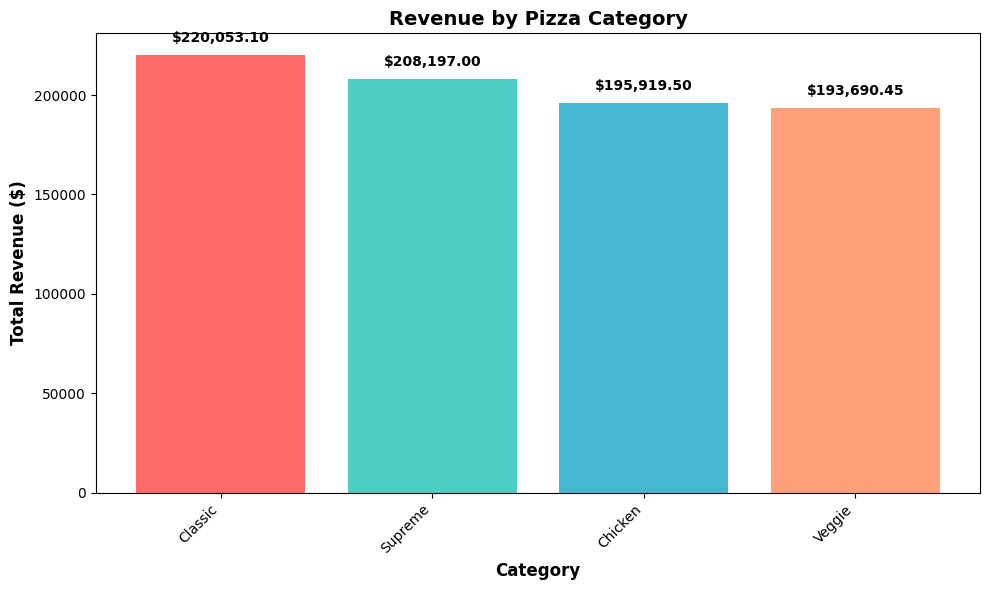

In [18]:
category_revenue = pd.read_sql_query(text("""select pt.category as categories , round(sum(p.price * od.quantity),2) as total_revenue from pizza_types_clean as pt
inner join pizzas_clean as p on p.pizza_type_id = pt.pizza_type_id
inner join order_details_clean as od on od.pizza_id = p.pizza_id
group by categories order by total_revenue desc; """),engine)
display(category_revenue)


plt.figure(figsize=(10, 6))
plt.bar(category_revenue['categories'], category_revenue['total_revenue'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Revenue by Pizza Category', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for i, (category, revenue) in enumerate(zip(category_revenue['categories'], category_revenue['total_revenue'])):
    plt.text(i, revenue + 5000, f'${revenue:,.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

3 . How does revenue break down by pizza size (S/M/L/XL/XXL)?

,pizza_size,total_revenue
0,L,375318.70
1,M,249382.25
2,S,178076.50
3,XL,14076.00
4,XXL,1006.60


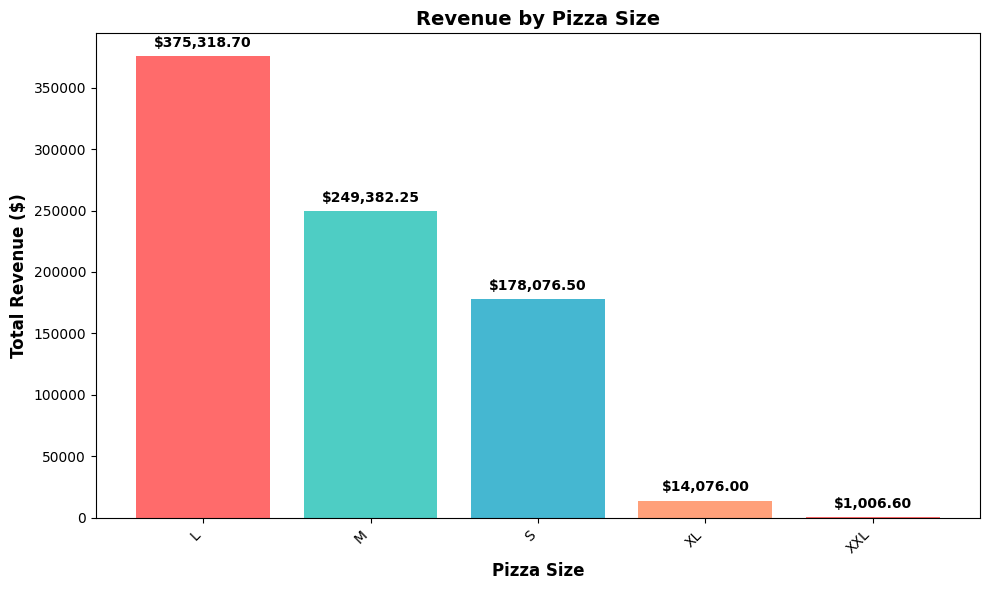

In [19]:
size_revenue = pd.read_sql_query(text("""select p.size as pizza_size ,  round(sum(p.price * od.quantity),2) as total_revenue 
from  pizzas_clean as p inner join order_details_clean as od  on p.pizza_id = od.pizza_id
group by pizza_size order by total_revenue desc;"""),engine)
display(size_revenue)


plt.figure(figsize=(10, 6))
plt.bar(size_revenue['pizza_size'], size_revenue['total_revenue'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A'])
plt.xlabel('Pizza Size', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Revenue by Pizza Size', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for i, (size, revenue) in enumerate(zip(size_revenue['pizza_size'], size_revenue['total_revenue'])):
    plt.text(i, revenue + 5000, f'${revenue:,.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

4 . What are the top 5 best-selling pizzas by revenue?

,pizza_,total_revenue
0,The Thai Chicken Pizza,43434.25
1,The Barbecue Chicken Pizza,42768.00
2,The California Chicken Pizza,41409.50
3,The Classic Deluxe Pizza,38180.50
4,The Spicy Italian Pizza,34831.25


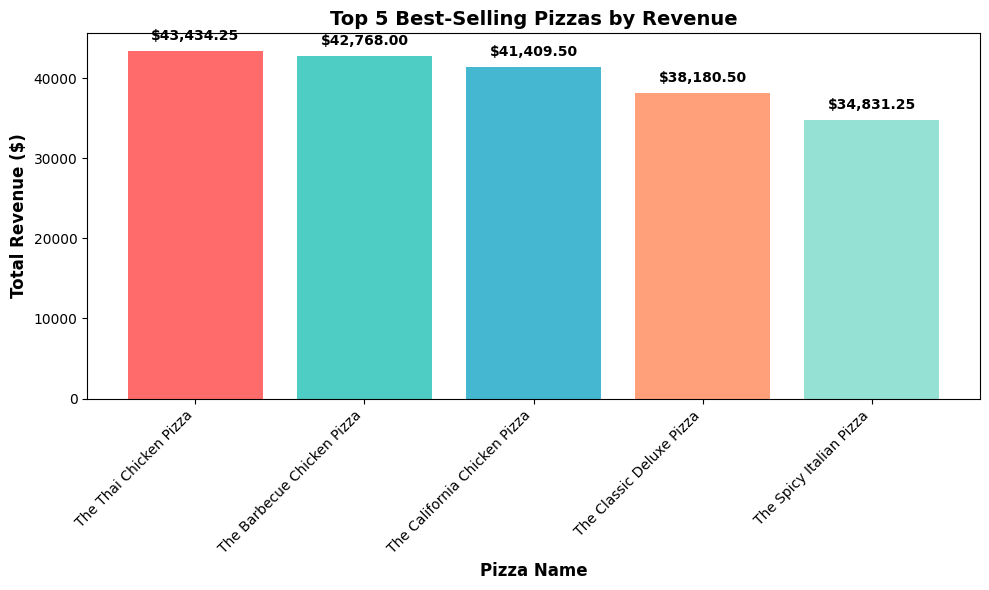

In [25]:
best_sell_pizza = pd.read_sql_query(text("""select pt.name as pizza_ , round(sum(p.price * od.quantity),2) as total_revenue 
from pizzas_clean as p inner join  order_details_clean as od on p.pizza_id = od.pizza_id
inner join pizza_types_clean as pt on pt.pizza_type_id = p.pizza_type_id
group by pizza_ order by total_revenue desc limit 5 ; """),engine)
display(best_sell_pizza)

plt.figure(figsize=(10, 6))
plt.bar(best_sell_pizza['pizza_'], best_sell_pizza['total_revenue'], color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#95E1D3'])
plt.xlabel('Pizza Name', fontsize=12, fontweight='bold')
plt.ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
plt.title('Top 5 Best-Selling Pizzas by Revenue', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')

# Add data labels on top of bars
for i, (pizza, revenue) in enumerate(zip(best_sell_pizza['pizza_'], best_sell_pizza['total_revenue'])):
    plt.text(i, revenue + 1000, f'${revenue:,.2f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

5 . What is the average order value (AOV)?

In [14]:
avg_order_val = pd.read_sql_query(text("""select count(distinct o.order_id) as total_order , round(sum(p.price * od.quantity),2) as total_revenue ,
round(sum(p.price * od.quantity) /count(distinct o.order_id),2 ) as aov
from orders_clean as o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on p.pizza_id = od.pizza_id; """),engine)
display(avg_order_val)

,total_order,total_revenue,aov
0,21350,817860.05,38.31


6 . How does revenue trend month by month?

,month_no,total_revenue
0,1,69793.30
1,2,65159.60
2,3,70397.10
3,4,68736.80
4,5,71402.75
5,6,68230.20
6,7,72557.90
7,8,68278.25
8,9,64180.05
9,10,64027.60


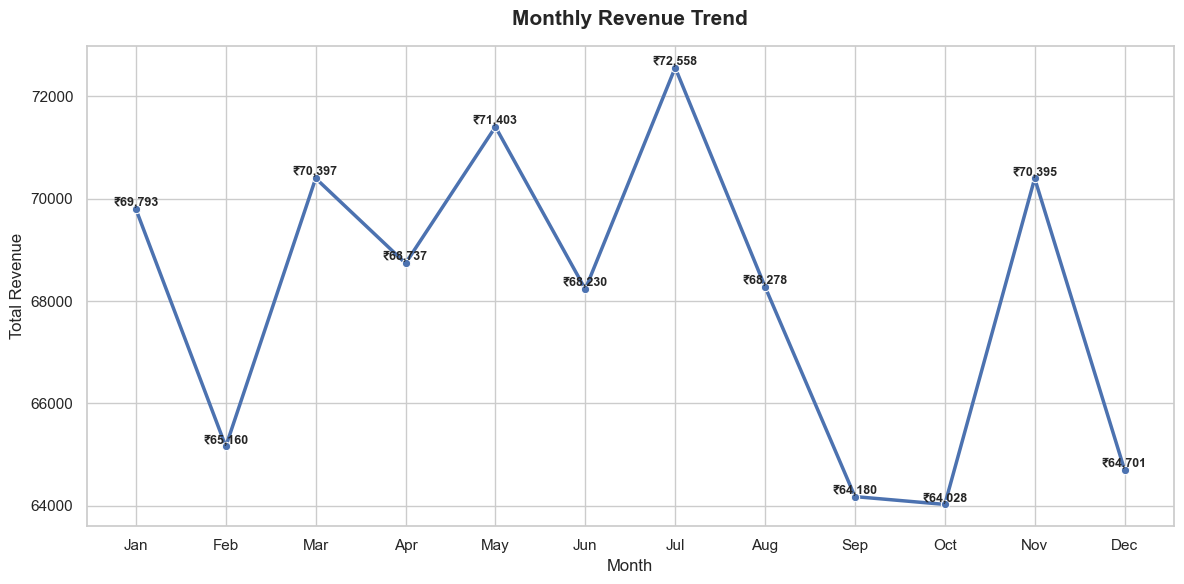

In [26]:
monthly_revenue = pd.read_sql_query(text("""select month(o.order_date) as month_no , round(sum(p.price * od.quantity),2) as total_revenue 
from orders_clean as  o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on od.pizza_id = p.pizza_id
group by month_no order by month_no;"""),engine)
display(monthly_revenue)

# Month names
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

# Create month name column
monthly_revenue["month_name"] = monthly_revenue["month_no"].map(month_names)

# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Line chart
ax = sns.lineplot(
    data=monthly_revenue,
    x="month_name",
    y="total_revenue",
    marker="o",
    linewidth=2.5
)

# Title and labels
ax.set_title(
    "Monthly Revenue Trend",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Total Revenue", fontsize=12)

# Add data labels
for x, y in zip(
    monthly_revenue["month_name"],
    monthly_revenue["total_revenue"]
):
    ax.text(
        x,
        y,
        f"₹{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

# Make sure months appear in correct order
ax.set_xticks(range(len(monthly_revenue["month_name"])))
ax.set_xticklabels(monthly_revenue["month_name"])

plt.tight_layout()
plt.show()

7 . Which day of the week generates the most orders and revenue?

,day_name,total_orders,total_revenue
0,Sunday,2624,99203.50
1,Monday,2794,107329.55
2,Tuesday,2973,114133.80
3,Wednesday,3024,114408.40
4,Thursday,3239,123528.50
5,Friday,3538,136073.90
6,Saturday,3158,123182.40


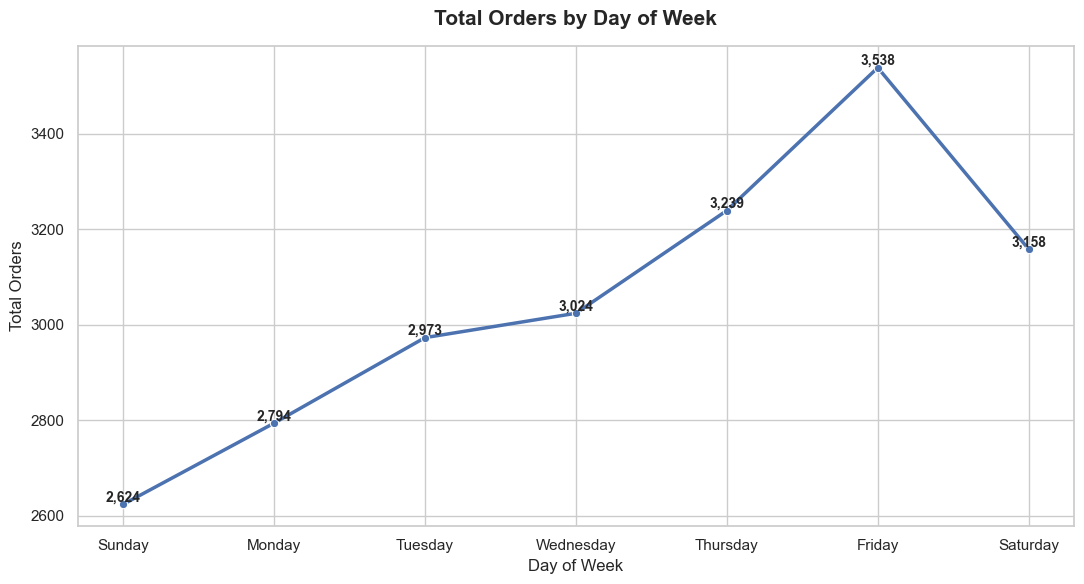

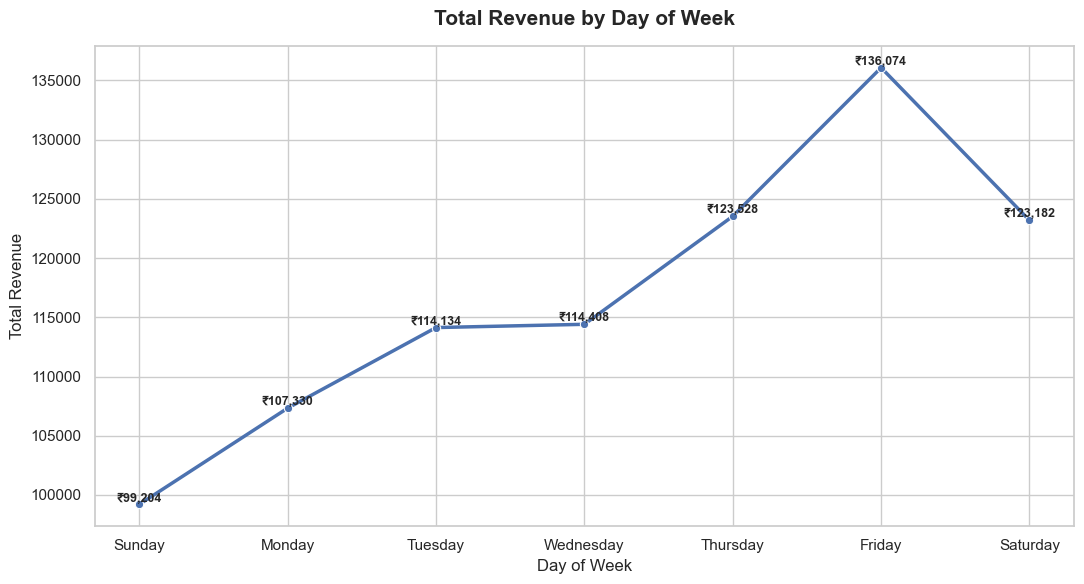

In [ ]:
day_of_week = pd.read_sql_query(text("""select dayname(o.order_date) as day_name , count(distinct o.order_id) as total_orders,
round(sum(p.price * od.quantity),2) as total_revenue 
from orders_clean as o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on p.pizza_id = od.pizza_id 
group by dayofweek(o.order_date) , day_name order by dayofweek(o.order_date); 
 """),engine)
display(day_of_week)


sns.set_theme(style="whitegrid")

plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=day_of_week,
    x="day_name",
    y="total_orders",
    marker="o",
    linewidth=2.5
)

ax.set_title(
    "Total Orders by Day of Week",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Orders")

# Data labels
for x, y in zip(day_of_week["day_name"], day_of_week["total_orders"]):
    ax.text(
        x,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


plt.figure(figsize=(11, 6))

ax = sns.lineplot(
    data=day_of_week,
    x="day_name",
    y="total_revenue",
    marker="o",
    linewidth=2.5
)

ax.set_title(
    "Total Revenue by Day of Week",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Revenue")

# Data labels
for x, y in zip(day_of_week["day_name"], day_of_week["total_revenue"]):
    ax.text(
        x,
        y,
        f"₹{y:,.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

8 . What are the peak order hours during the day?

,hours,total_order
0,9,1
1,10,8
2,11,1231
3,12,2520
4,13,2455
5,14,1472
6,15,1468
7,16,1920
8,17,2336
9,18,2399


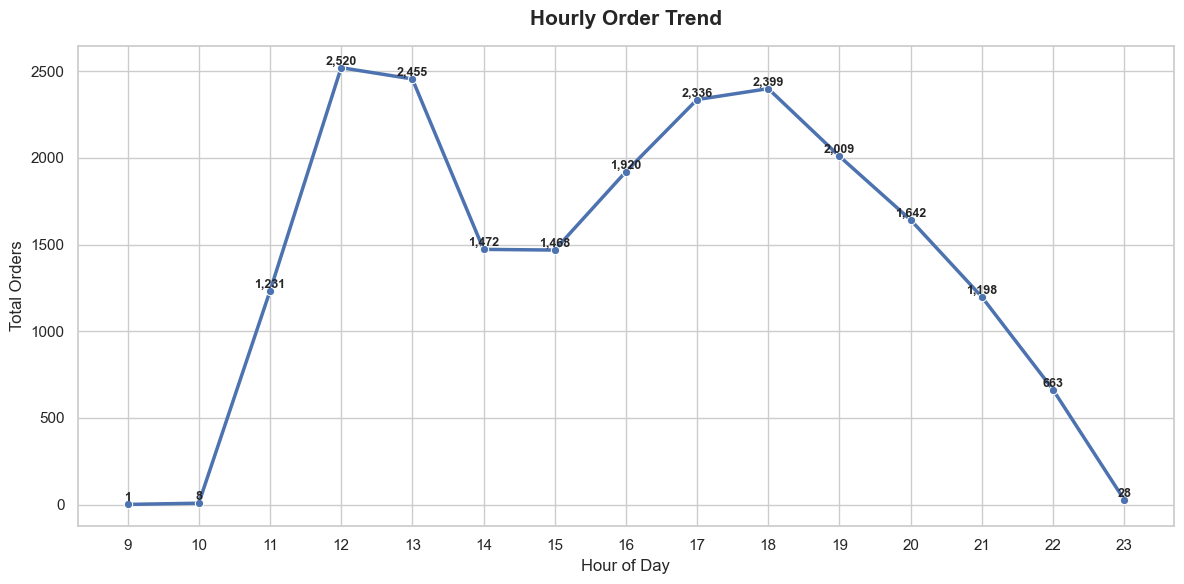

In [28]:
hourly_orders = pd.read_sql_query(text("""select hour(order_time) as hours , count(order_id) as total_order from orders_clean group by hours order by hours """),engine)
display(hourly_orders)


# Set style
sns.set_theme(style="whitegrid")

# Create figure
plt.figure(figsize=(12, 6))

# Line chart
ax = sns.lineplot(
    data=hourly_orders,
    x="hours",
    y="total_order",
    marker="o",
    linewidth=2.5
)

# Title and labels
ax.set_title(
    "Hourly Order Trend",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Hour of Day", fontsize=12)
ax.set_ylabel("Total Orders", fontsize=12)

# Show every hour
ax.set_xticks(hourly_orders["hours"])

# Data labels
for x, y in zip(
    hourly_orders["hours"],
    hourly_orders["total_order"]
):
    ax.text(
        x,
        y,
        f"{int(y):,}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

9 . What is the month-over-month revenue growth rate?

In [31]:
revenue_growth = pd.read_sql_query(text("""with a as (select month(o.order_date) as month_no , round(sum(p.price * od.quantity),2) as montly_revenue , 
lag(round(sum(p.price * od.quantity),2)) over(order by month(o.order_date)) as previous_month_revenu 
from orders_clean as  o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on od.pizza_id = p.pizza_id
group by month_no order by month_no)
select * , round(((montly_revenue - previous_month_revenu) / previous_month_revenu) * 100 , 2) as monthly_growth_rate
from a ;"""),engine)
display(revenue_growth)

,month_no,montly_revenue,previous_month_revenu,monthly_growth_rate
0,1,69793.30,NaN,NaN
1,2,65159.60,69793.30,-6.64
2,3,70397.10,65159.60,8.04
3,4,68736.80,70397.10,-2.36
4,5,71402.75,68736.80,3.88
5,6,68230.20,71402.75,-4.44
6,7,72557.90,68230.20,6.34
7,8,68278.25,72557.90,-5.90
8,9,64180.05,68278.25,-6.00
9,10,64027.60,64180.05,-0.24


10 . Do larger pizza sizes (L/XL/XXL) drive more revenue per order, or just more orders?

,size,orders_with_this_size,avg_full_order_value
0,XXL,28,70.39
1,XL,544,68.08
2,L,12736,48.41
3,M,11159,47.06
4,S,10490,45.19


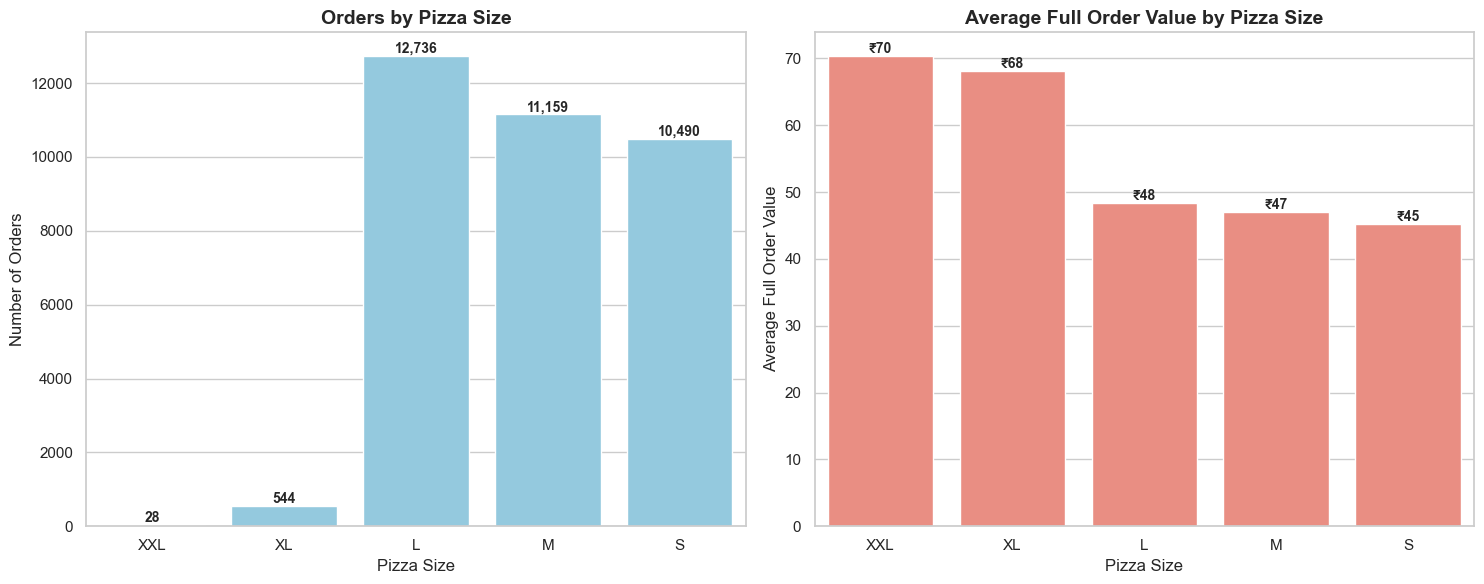

In [30]:
revenu_per_order = pd.read_sql_query(text("""WITH order_size AS (
    SELECT DISTINCT o.order_id, p.size
    FROM orders_clean o
    INNER JOIN order_details_clean od ON o.order_id = od.order_id
    INNER JOIN pizzas_clean p ON p.pizza_id = od.pizza_id
),
order_totals AS (
    SELECT o.order_id, ROUND(SUM(p.price * od.quantity), 2) AS order_total
    FROM orders_clean o
    INNER JOIN order_details_clean od ON o.order_id = od.order_id
    INNER JOIN pizzas_clean p ON p.pizza_id = od.pizza_id
    GROUP BY o.order_id
)
SELECT 
    os.size,
    COUNT(DISTINCT os.order_id) AS orders_with_this_size,
    ROUND(AVG(ot.order_total), 2) AS avg_full_order_value
FROM order_size os
INNER JOIN order_totals ot ON os.order_id = ot.order_id
GROUP BY os.size
ORDER BY avg_full_order_value DESC;"""),engine)
display(revenu_per_order)

# Sort by average order value
plot_data = revenu_per_order.sort_values(
    by="avg_full_order_value",
    ascending=False
)

# Set style
sns.set_theme(style="whitegrid")

# Create subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# ---------------------------------------
# 1. Orders by Pizza Size
# ---------------------------------------
bars1 = sns.barplot(
    data=plot_data,
    x="size",
    y="orders_with_this_size",
    color="skyblue",
    ax=ax[0]
)

ax[0].set_title(
    "Orders by Pizza Size",
    fontsize=14,
    fontweight="bold"
)
ax[0].set_xlabel("Pizza Size")
ax[0].set_ylabel("Number of Orders")

# Data labels
for bar in bars1.patches:
    height = bar.get_height()

    ax[0].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )


# ---------------------------------------
# 2. Average Full Order Value
# ---------------------------------------
bars2 = sns.barplot(
    data=plot_data,
    x="size",
    y="avg_full_order_value",
    color="salmon",
    ax=ax[1]
)

ax[1].set_title(
    "Average Full Order Value by Pizza Size",
    fontsize=14,
    fontweight="bold"
)
ax[1].set_xlabel("Pizza Size")
ax[1].set_ylabel("Average Full Order Value")

# Data labels
for bar in bars2.patches:
    height = bar.get_height()

    ax[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"₹{height:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

# Improve spacing
plt.tight_layout()
plt.show()

11 . How does category performance shift between weekdays and weekends?

In [38]:
category_performance = pd.read_sql_query(text("""select case when dayname(o.order_date) in ("Saturday" , "Sunday")then "weekend"
else "weekdays"  end as day_name , pt.category as categories , 
count(distinct o.order_id) as total_orders,
sum(od.quantity) as qty , 
round(sum(p.price * od.quantity),2) as total_revenue 
from orders_clean as o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on p.pizza_id = od.pizza_id 
inner join pizza_types_clean as pt on pt.pizza_type_id = p.pizza_type_id
group by day_name, categories order by case when day_name = "weekdays" then 1 else 2 end ,  total_revenue desc;"""),engine)
display(category_performance)

,day_name,categories,total_orders,qty,total_revenue
0,weekdays,Classic,7855,10806.0,159876.80
1,weekdays,Supreme,6619,8712.0,151658.70
2,weekdays,Chicken,6225,8036.0,142419.00
3,weekdays,Veggie,6500,8492.0,141519.65
4,weekend,Classic,3004,4082.0,60176.30
5,weekend,Supreme,2466,3275.0,56538.30
6,weekend,Chicken,2311,3014.0,53500.50
7,weekend,Veggie,2441,3157.0,52170.80


12 . Which pizzas are "underperformers" (low revenue AND low quantity)?

In [44]:
low_performance = pd.read_sql_query(text("""select pt.name as pizza_ , round(sum(p.price * od.quantity),2) as total_revenue ,
sum(od.quantity) as qty
from pizzas_clean as p inner join  order_details_clean as od on p.pizza_id = od.pizza_id
inner join pizza_types_clean as pt on pt.pizza_type_id = p.pizza_type_id
group by pizza_ order by total_revenue , qty"""),engine)
display(low_performance)

,pizza_,total_revenue,qty
0,The Brie Carre Pizza,11588.50,490.0
1,The Green Garden Pizza,13955.75,997.0
2,The Spinach Supreme Pizza,15277.75,950.0
3,The Mediterranean Pizza,15360.50,934.0
4,The Spinach Pesto Pizza,15596.00,970.0
5,The Calabrese Pizza,15934.25,937.0
6,The Italian Vegetables Pizza,16019.25,981.0
7,The Soppressata Pizza,16425.75,961.0
8,The Chicken Pesto Pizza,16701.75,973.0
9,The Chicken Alfredo Pizza,16900.25,987.0


13 . What % of total revenue comes from each category

,categories,total_revenue,pct_of_total_revenue
0,Classic,220053.10,26.91
1,Supreme,208197.00,25.46
2,Chicken,195919.50,23.96
3,Veggie,193690.45,23.68


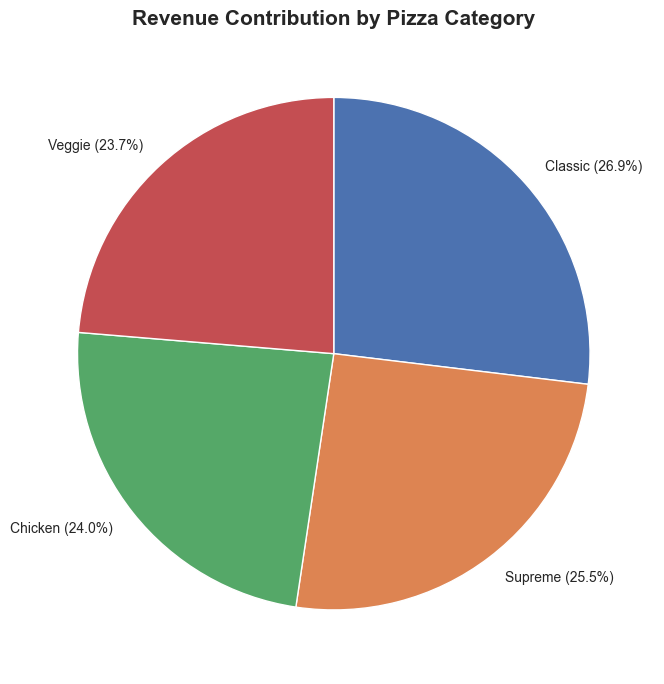

In [31]:
total_revenue_per = pd.read_sql_query(text("""select pt.category as categories , round(sum(p.price * od.quantity),2) as total_revenue ,
round(100.0 * (sum(p.price * od.quantity)) / sum(sum(p.price * od.quantity)) over(),2) as pct_of_total_revenue
from pizza_types_clean as pt
inner join pizzas_clean as p on p.pizza_type_id = pt.pizza_type_id
inner join order_details_clean as od on od.pizza_id = p.pizza_id
group by categories order by total_revenue desc; """),engine)
display(total_revenue_per)

labels = [
    f"{category} ({pct:.1f}%)"
    for category, pct in zip(
        total_revenue_per["categories"],
        total_revenue_per["pct_of_total_revenue"]
    )
]

plt.figure(figsize=(9, 7))

plt.pie(
    total_revenue_per["pct_of_total_revenue"],
    labels=labels,
    startangle=90,
    counterclock=False,
    textprops={"fontsize": 10}
)

plt.title(
    "Revenue Contribution by Pizza Category",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

14 . Which orders have unusually high item counts (bulk orders)?

In [51]:
bulk_order = pd.read_sql_query(text("""select o.order_id , sum(od.quantity) as qty from orders_clean as o inner join order_details_clean as od on o.order_id = od.order_id group by o.order_id having sum(od.quantity) >= 10"""),engine)
display(bulk_order)

,order_id,qty
0,17,11.0
1,92,10.0
2,144,14.0
3,271,13.0
4,330,15.0
...,...,...
336,20463,10.0
337,20467,11.0
338,20885,15.0
339,21228,15.0


15 . How does AOV differ between weekdays and weekends?

In [16]:
weekday_weekend_aov = pd.read_sql_query(text("""select case when dayname(o.order_date) in ("Saturday" , "Sunday")then "weekend"
else "weekdays"  end as day_name , round(sum(p.price * od.quantity) /count(distinct o.order_id),2) as aov
from orders_clean as o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on p.pizza_id = od.pizza_id 
inner join pizza_types_clean as pt on pt.pizza_type_id = p.pizza_type_id
group by day_name order by aov desc;   """),engine)
display(weekday_weekend_aov)

,day_name,aov
0,weekend,38.46
1,weekdays,38.25


16 . Which pizza is the #1 seller in each individual month?

In [ ]:
best_sell_pizza  = pd.read_sql_query(text("""with monthly_qty as (select month(o.order_date) as order_month , pt.name as pizza_name , sum(od.quantity) as qty
from orders_clean as o inner join order_details_clean as od on o.order_id = od.order_id
inner join pizzas_clean as p on od.pizza_id = p.pizza_id
inner join pizza_types_clean as pt on pt.pizza_type_id = p.pizza_type_id
group by order_month , pizza_name ),
rankes as (select * , dense_rank() over(partition by order_month order by qty desc) as qty_rnk from monthly_qty)
select * from rankes where qty_rnk = 1; """),engine)
display(best_sell_pizza)

,order_month,pizza_name,qty,qty_rnk
0,1,The Pepperoni Pizza,239.0,1
1,2,The Pepperoni Pizza,205.0,1
2,3,The Barbecue Chicken Pizza,231.0,1
3,4,The Hawaiian Pizza,219.0,1
4,5,The Pepperoni Pizza,241.0,1
5,6,The California Chicken Pizza,222.0,1
6,7,The Classic Deluxe Pizza,227.0,1
7,8,The California Chicken Pizza,231.0,1
8,9,The Classic Deluxe Pizza,209.0,1
9,10,The Pepperoni Pizza,199.0,1


17 . Rank pizzas within their own category by revenue, and find the top pizza per category.

In [7]:
category_pizza = pd.read_sql_query(text("""with revenue as (select pt.category as pizza_cat  , pt.name as pizza_name , sum(p.price * od.quantity) as total_revenue
from pizzas_clean as p inner join order_details_clean as od on p.pizza_id = od.pizza_id
inner join pizza_types_clean as pt on pt.pizza_type_id = p.pizza_type_id
group by pizza_cat , pizza_name) ,
ranked as (select * , dense_rank() over (partition by pizza_cat order by total_revenue desc) as rnk from revenue)
select * from ranked where rnk = 1; """),engine)
display(category_pizza)

,pizza_cat,pizza_name,total_revenue,rnk
0,Chicken,The Thai Chicken Pizza,43434.25,1
1,Classic,The Classic Deluxe Pizza,38180.50,1
2,Supreme,The Spicy Italian Pizza,34831.25,1
3,Veggie,The Four Cheese Pizza,32265.70,1


18 . Find any calendar dates with zero orders.

In [17]:
zero_order = pd.read_sql_query(text("""WITH RECURSIVE calendar AS (
    SELECT MIN(order_date) AS cal_date FROM orders_clean
    UNION ALL
    SELECT cal_date + INTERVAL 1 DAY FROM calendar
    WHERE cal_date < (SELECT MAX(order_date) FROM orders_clean)
)
SELECT c.cal_date
FROM calendar c
LEFT JOIN orders_clean o ON c.cal_date = o.order_date
WHERE o.order_id IS NULL
ORDER BY c.cal_date; """),engine)
display(zero_order)

,cal_date
0,2015-09-24
1,2015-09-25
2,2015-10-05
3,2015-10-12
4,2015-10-19
5,2015-10-26
6,2015-12-25
